In [1]:
import matplotlib.pyplot as plt
import numpy as np
from p3.aoSystem.fourierModel import fourierModel

Cupy import failed. P3 will fall back to CPU use.
Cupy import failed. MASTSEL will fall back to CPU use.


In [2]:
fao = fourierModel(path_ini='/raid1/mmenessini/git/P3/p3/aoSystem/parFiles/SOUL.ini',display=False, verbose=True,getErrorBreakDown=True)

extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2

_____ ERROR BREAKDOWN  ON-AXIS_____
------------------------------------------
.Image Strehl at 2.15micron:	94.91%
.Maréchal Strehl at 2.15micron:	94.83%
.Residual wavefront error:	78.84nm
.NCPA residual:			0.00nm
.Fitting error:			71.61nm
.Differential refraction:	0.00nm
.Chromatic error:		12.76nm
.Aliasing error:		3.46nm
.Noise error:			20.75nm
.Spatio-temporal error:		21.93nm
.Wind-shake error:		0.00nm
.Additionnal jitter:		0.00mas / 0.00nm
.Extra error:			0.00nm
-------------------------------------------
.Sole servoLag error:		21.93nm
.Sole reconstruction error:	0.00nm
-------------------------------------------
.Sole anisoplanatism error:	0.00nm
-------------------------------------------

EXECUTION TIME BREAKDOWN

Total calculation time:                          242.1 ms
AO system model initialization:                    3.6 ms

-

Text(0.5, 1.0, 'Aliasing')

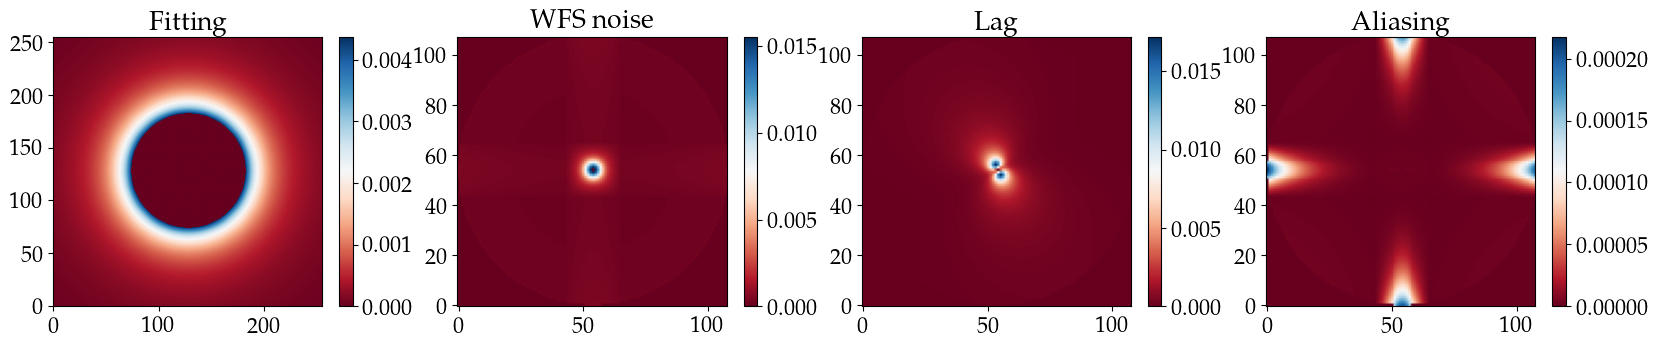

In [3]:
aliasPSD = fao.aliasingPSD()
servoLagPSD = fao.servoLagPSD()
fittingPSD = fao.fittingPSD()
noisePSD = fao.noisePSD()

plt.figure(figsize=(20,3.5))
plt.subplot(1,4,1)
plt.imshow(fittingPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Fitting')
plt.subplot(1,4,2)
plt.imshow(noisePSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('WFS noise')
plt.subplot(1,4,3)
plt.imshow(servoLagPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Lag')
plt.subplot(1,4,4)
plt.imshow(aliasPSD,origin='lower',cmap='RdBu')
plt.colorbar()
plt.title('Aliasing')

In [ ]:
def get_flux(fao, mag:float, thrp:float=0.2, B0=10**10):
    area = np.pi/4*fao.ao.tel.D**2*(1-fao.ao.tel.obsRatio**2)
    return area * thrp * B0 * 10**(-mag/2.5)

def update_ao_pars(fao, delay=None, gain=None, mag=None, fs=None, binning:int=None):
    if gain is not None:
        fao.ao.rtc.holoop['gain'] = gain
        
    if delay is not None:
        fao.ao.rtc.holoop['delay'] = delay
        
    if fs is not None:
        fao.ao.rtc.holoop['rate'] = fs
    

def get_error_breakdown(fao):
    fao.ao.error = False
    fao.getErrorBreakdown = True
    fao.initComputations()

    idCenter = fao.ao.src.zenith.argmin()
    error = {'fitting': fao.wfeFit, 'noise': fao.wfeN, 'aliasing': fao.wfeAl, 'lag': fao.wfeS[idCenter], 'total': fao.wfeTot[idCenter]}

    return error



In [6]:
eb = get_error_breakdown(fao)

extra error in nm RMS:  0
extra error spatial frequency exponent:  -2
extra error in nm RMS (LO):  0
extra error spatial frequency exponent (LO):  -2

_____ ERROR BREAKDOWN  ON-AXIS_____
------------------------------------------
.Image Strehl at 2.15micron:	94.91%
.Maréchal Strehl at 2.15micron:	94.83%
.Residual wavefront error:	78.84nm
.NCPA residual:			0.00nm
.Fitting error:			71.61nm
.Differential refraction:	0.00nm
.Chromatic error:		12.76nm
.Aliasing error:		3.46nm
.Noise error:			20.75nm
.Spatio-temporal error:		21.93nm
.Wind-shake error:		0.00nm
.Additionnal jitter:		0.00mas / 0.00nm
.Extra error:			0.00nm
-------------------------------------------
.Sole servoLag error:		21.93nm
.Sole reconstruction error:	0.00nm
-------------------------------------------
.Sole anisoplanatism error:	0.00nm
-------------------------------------------

EXECUTION TIME BREAKDOWN

Total calculation time:                          146.0 ms
AO system model initialization:                    3.6 ms

-

In [7]:
print(eb)

{'fitting': 71.61429477285542, 'noise': array([20.75469006]), 'aliasing': 3.4555171868061176, 'lag': 21.931072673094867, 'total': 78.83557100138833}
